# 05d - Task 3: Hyperparameter tuning (LinearSVC)

Parallel variant of the 05/05b/05c searches, applied to LinearSVC - the last member
of the linear family that has never been tuned. Its 04_models baseline scored 0.7228,
third among the linear models and ahead of untuned ElasticNet (0.7196).

**Why LinearSVC and not XGBoost/HistGB.** The Kaggle results so far invert the local
ranking: LightGBM leads local CV by ~0.015 but trails on the leaderboard by ~0.029
(0.65738 vs ElasticNet's 0.69576). Gradient boosting generalizes *worse* across the
documented train-to-test distribution shift than the linear models do, so the marginal
effort goes into the linear family rather than into two more boosting variants.

LinearSVC also brings genuine diversity to the ensemble in `07_linear_ensemble.ipynb`:
Ridge and ElasticNet are both logistic regression and will be heavily correlated, while
a hinge-loss max-margin classifier fits a different objective.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib
import warnings

from scipy.stats import loguniform
from sklearn.model_selection import ParameterSampler, ParameterGrid
from sklearn.svm import LinearSVC
from sklearn.exceptions import ConvergenceWarning

from src import paths, data, evaluation, tuning
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

X_dev, y_dev = X[dev_idx], y[dev_idx]

# Guard against a silent re-split: the locked dev partition is 16000 of 20000 rows.
assert X_dev.shape == (16000, 5000), X_dev.shape
print(f"dev: {X_dev.shape}, machine-class share {y_dev.mean():.4f}")

dev: (16000, 5000), machine-class share 0.6252


In [3]:
# Edit this before running your own portion of the search - it tags every trial file
# you produce, so your results are distinguishable from teammates' and nothing gets
# silently overwritten when files are merged (e.g. via git pull).
OWNER = "solo_demo"  # e.g. "alice_C_hi" for a named sub-range, see section 2

## 2. Search space - what each knob does and why this range

Fixed, not searched: `class_weight="balanced"` (05b already established this is
necessary - unweighted linear models at low C collapse to the 0.3847 majority-class
floor), `random_state=42`, and `max_iter=5000` (generous, so convergence is not the
thing being measured). `dual="auto"` lets sklearn pick the solver form; it matters
because `loss="hinge"` is only available in the dual formulation.

Knobs searched:

- `C` (log-uniform, 0.001-10): inverse regularization strength, the dominant knob.
  Range capped at 10 rather than ElasticNet's 100 because both tuned logistic models
  landed low (Ridge 1.48, ElasticNet 2.29) and the interest here is the *lower* end.
- `loss` (`"squared_hinge"` vs `"hinge"`): squared_hinge is the sklearn default and
  penalizes margin violations quadratically, so it reacts more strongly to outliers;
  plain hinge is the textbook SVM loss and is more tolerant of them. Worth testing
  both rather than accepting the default, since which one wins is an empirical
  question about how noisy the margin region is.

### Selection rule: bias toward regularization

This search deliberately does **not** take a plain CV-argmax. Among trials whose CV
mean is within one standard deviation of the best, it picks the one with the **smallest
`C`** (strongest regularization).

The justification is the leaderboard evidence, not a hunch: local CV and the real test
set disagree, and they disagree in a way that tracks model variance. LightGBM (highest
capacity) loses 0.086 going from local to Kaggle, Ridge (lowest) loses 0.052. When two
settings are statistically indistinguishable locally, the lower-variance one is the
better bet on the shifted distribution. Both the argmax choice and the regularized
choice are printed in section 6 so the cost of this decision is visible and can be
reported honestly.

Sub-range for team splitting: split by `C` band (e.g. one person covers 0.001-0.1,
another 0.1-10) and record which band in the `OWNER` string above.

## 3. Stage 1 - coarse search

Draws random combinations from the distributions above and scores each via
`tuning.run_trial` - the same resumable/mergeable mechanism as 05b/05c, so an
interrupted sweep resumes rather than restarting.

Convergence warnings are captured rather than printed inline (LinearSVC is chatty on
5000 sparse features); the count is reported afterward so a genuine convergence problem
still surfaces.

In [4]:
param_dist = {
    "C": loguniform(0.001, 10),
    "loss": ["squared_hinge", "hinge"],
}

N_ITER = 12
sampler = ParameterSampler(param_dist, n_iter=N_ITER, random_state=42)

n_converge_warnings = 0
for i, params in enumerate(sampler):
    print(f"[{i + 1}/{N_ITER}] {params}")
    est = LinearSVC(
        class_weight="balanced", max_iter=5000, dual="auto", random_state=42, **params,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        result = tuning.run_trial("linearsvc_stage1", OWNER, est, params, X_dev, y_dev, cv)
    n_converge_warnings += sum(issubclass(w.category, ConvergenceWarning) for w in caught)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")

print(f"\nConvergence warnings raised during stage 1: {n_converge_warnings}")

[1/12] {'C': np.float64(0.03148911647956861), 'loss': 'squared_hinge'}


  mean=0.7068  std=0.0061
[2/12] {'C': np.float64(0.0054167545832474575), 'loss': 'hinge'}


  mean=0.6324  std=0.0079
[3/12] {'C': np.float64(0.24810409748678125), 'loss': 'squared_hinge'}


  mean=0.7272  std=0.0047
[4/12] {'C': np.float64(0.06071989493441298), 'loss': 'squared_hinge'}


  mean=0.7192  std=0.0049
[5/12] {'C': np.float64(0.0017073967431528124), 'loss': 'hinge'}


...

  mean=0.6323  std=0.0078
[9/12] {'C': np.float64(2.1368329072358767), 'loss': 'hinge'}


  mean=0.7219  std=0.0032
[10/12] {'C': np.float64(0.0010071984838809194), 'loss': 'hinge'}


  mean=0.6323  std=0.0078
[11/12] {'C': np.float64(0.00541524411940254), 'loss': 'hinge'}


  mean=0.6323  std=0.0078
[12/12] {'C': np.float64(0.27964859516062457), 'loss': 'squared_hinge'}


  mean=0.7276  std=0.0043

Convergence warnings raised during stage 1: 0


## 4. Merge stage-1 results across teammates

Pulls in every stage-1 trial file present on disk - all owners, all sub-ranges.

In [5]:
stage1_trials = tuning.load_trials("linearsvc_stage1")
print(f"{len(stage1_trials)} stage-1 trials merged, from owners: "
      f"{sorted(stage1_trials['owner'].unique())}")
print(stage1_trials[["owner", "params", "mean", "std"]].to_string())

center = stage1_trials.iloc[0]["params"]
print("\nMerged winner, centering stage 2 on:", center)

12 stage-1 trials merged, from owners: ['solo_demo']
        owner                                               params      mean       std
0   solo_demo  {'C': 0.27964859516062457, 'loss': 'squared_hinge'}  0.727575  0.004293
1   solo_demo  {'C': 0.24810409748678125, 'loss': 'squared_hinge'}  0.727249  0.004748
2   solo_demo            {'C': 0.679657809075816, 'loss': 'hinge'}  0.725034  0.004444
3   solo_demo           {'C': 2.1368329072358767, 'loss': 'hinge'}  0.721931  0.003223
4   solo_demo  {'C': 0.06071989493441298, 'loss': 'squared_hinge'}  0.719169  0.004883
5   solo_demo  {'C': 0.03148911647956861, 'loss': 'squared_hinge'}  0.706811  0.006071
6   solo_demo        {'C': 0.0017073967431528124, 'loss': 'hinge'}  0.632356  0.007862
7   solo_demo        {'C': 0.0054167545832474575, 'loss': 'hinge'}  0.632356  0.007862
8   solo_demo        {'C': 0.0016813042706040676, 'loss': 'hinge'}  0.632292  0.007761
9   solo_demo          {'C': 0.00541524411940254, 'loss': 'hinge'}  0.632292 

## 5. Stage 2 - refined search around the merged winner

Refines `C` around the stage-1 winner. The band is deliberately asymmetric - it reaches
further *below* the winner than above (down to C/4, up to 2C) - so the regularized end
of the space is sampled densely enough for the section-2 selection rule to have real
candidates to choose from. Both `loss` values are re-tested at the refined `C` values
rather than freezing the stage-1 winner's loss, since the better loss can change once
`C` moves.

In [6]:
c0 = center["C"]
refined_grid = {
    "C": sorted(round(c0 * m, 6) for m in (0.25, 0.5, 1.0, 2.0)),
    "loss": ["squared_hinge", "hinge"],
}
combos = list(ParameterGrid(refined_grid))
print(f"Refined grid: {len(combos)} combinations")

# Kept separate from the full merged history (which can mix slightly different grids
# across reruns) so the plot below stays a clean, aligned rectangle.
grid_results = []
n_converge_warnings = 0
for i, params in enumerate(combos):
    print(f"[{i + 1}/{len(combos)}] {params}")
    est = LinearSVC(
        class_weight="balanced", max_iter=5000, dual="auto", random_state=42, **params,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        result = tuning.run_trial("linearsvc_stage2", OWNER, est, params, X_dev, y_dev, cv)
    n_converge_warnings += sum(issubclass(w.category, ConvergenceWarning) for w in caught)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")
    grid_results.append({"C": params["C"], "loss": params["loss"],
                          "mean": result["mean"], "std": result["std"]})

print(f"\nConvergence warnings raised during stage 2: {n_converge_warnings}")

Refined grid: 8 combinations
[1/8] {'C': 0.069912, 'loss': 'squared_hinge'}


  mean=0.7220  std=0.0054
[2/8] {'C': 0.069912, 'loss': 'hinge'}


  mean=0.6150  std=0.0094
[3/8] {'C': 0.139824, 'loss': 'squared_hinge'}


  mean=0.7275  std=0.0040
[4/8] {'C': 0.139824, 'loss': 'hinge'}


  mean=0.6768  std=0.0066
[5/8] {'C': 0.279649, 'loss': 'squared_hinge'}


  mean=0.7276  std=0.0043
[6/8] {'C': 0.279649, 'loss': 'hinge'}


  mean=0.7145  std=0.0051
[7/8] {'C': 0.559297, 'loss': 'squared_hinge'}


  mean=0.7258  std=0.0036
[8/8] {'C': 0.559297, 'loss': 'hinge'}


  mean=0.7235  std=0.0045

Convergence warnings raised during stage 2: 0


### Visualize the refined search

Macro F1 against `C` for each loss, with error bars at +/- 1 CV standard deviation.
The shaded band marks the "within 1 std of best" region that the section-2 selection
rule treats as statistically tied - anything inside it is a legitimate candidate, and
the rule takes the leftmost (most regularized) one.

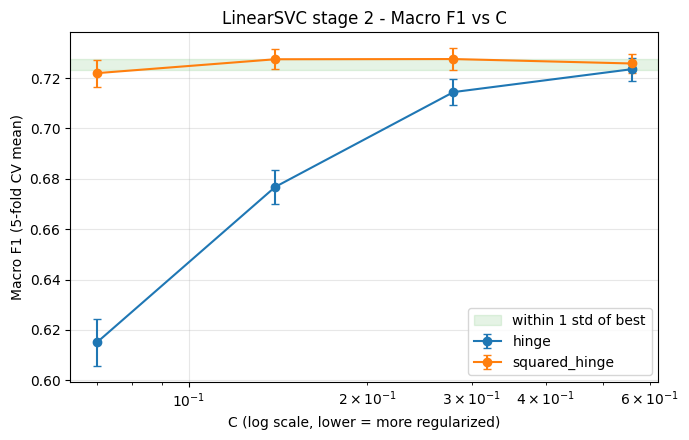

In [7]:
grid_df = pd.DataFrame(grid_results)

best_row = grid_df.loc[grid_df["mean"].idxmax()]
tie_floor = best_row["mean"] - best_row["std"]

fig, ax = plt.subplots(figsize=(7, 4.5))
for loss, sub in grid_df.groupby("loss"):
    sub = sub.sort_values("C")
    ax.errorbar(sub["C"], sub["mean"], yerr=sub["std"], marker="o",
                capsize=3, label=loss)

ax.axhspan(tie_floor, best_row["mean"], alpha=0.12, color="tab:green",
           label="within 1 std of best")
ax.set_xscale("log")
ax.set_xlabel("C (log scale, lower = more regularized)")
ax.set_ylabel("Macro F1 (5-fold CV mean)")
ax.set_title("LinearSVC stage 2 - Macro F1 vs C")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "linearsvc_stage2_C_sweep.png", dpi=120)
plt.show()

## 6. Select winner + persist params and fitted model

Selection uses the combined stage-1 + stage-2 pool, then applies the
bias-toward-regularization rule from section 2. Picking from stage 2 in isolation risks
a silent regression below the stage-1 winner - the same trap that was fixed in
05_tuning.ipynb.

In [8]:
stage2_trials = tuning.load_trials("linearsvc_stage2")
all_trials = pd.concat([stage1_trials, stage2_trials], ignore_index=True).sort_values(
    "mean", ascending=False
).reset_index(drop=True)

argmax_trial = all_trials.iloc[0]
print(f"Trials: stage 1 ({len(stage1_trials)}) + stage 2 ({len(stage2_trials)}) "
      f"= {len(all_trials)} total")
print(f"Plain CV-argmax:  {argmax_trial['params']}  ->  {argmax_trial['mean']:.4f}")

# The section-2 rule: among trials statistically tied with the best (within 1 std of
# the best trial's own CV spread), take the most regularized. Lower variance is the
# better bet across the documented train-to-test shift.
tied = all_trials[all_trials["mean"] >= argmax_trial["mean"] - argmax_trial["std"]].copy()
tied["C"] = tied["params"].apply(lambda p: p["C"])
chosen = tied.sort_values("C").iloc[0]
best_params = chosen["params"]

print(f"\n{len(tied)} trials tied within 1 std (>= {argmax_trial['mean'] - argmax_trial['std']:.4f})")
print(f"Regularized pick: {best_params}  ->  {chosen['mean']:.4f} (std {chosen['std']:.4f})")
print(f"Cost of the rule vs plain argmax: {chosen['mean'] - argmax_trial['mean']:+.4f} CV Macro F1")

Trials: stage 1 (12) + stage 2 (8) = 20 total
Plain CV-argmax:  {'C': 0.27964859516062457, 'loss': 'squared_hinge'}  ->  0.7276

7 trials tied within 1 std (>= 0.7233)
Regularized pick: {'C': 0.139824, 'loss': 'squared_hinge'}  ->  0.7275 (std 0.0040)
Cost of the rule vs plain argmax: -0.0001 CV Macro F1


In [9]:
paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
with open(paths.DATA_PROCESSED / "best_linearsvc_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_est = LinearSVC(
    class_weight="balanced", max_iter=5000, dual="auto", random_state=42, **best_params,
)
final_est.fit(X_dev, y_dev)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_est, paths.MODELS / "best_linearsvc_tuned.pkl")

metadata = {
    "model": "linearsvc",
    "params": best_params,
    "cv_mean_f1": chosen["mean"],
    "cv_std_f1": chosen["std"],
    "argmax_params": argmax_trial["params"],
    "argmax_cv_mean_f1": argmax_trial["mean"],
    "selection_rule": "smallest C among trials within 1 std of CV argmax",
    "n_stage1_trials": len(stage1_trials),
    "n_stage2_trials": len(stage2_trials),
}
with open(paths.MODELS / "best_linearsvc_tuned.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best_linearsvc_params.json, best_linearsvc_tuned.pkl, "
      "best_linearsvc_tuned.json")

Saved best_linearsvc_params.json, best_linearsvc_tuned.pkl, best_linearsvc_tuned.json


## Discussion / carry-forward -> `06d_holdout_linearsvc.ipynb`

**Result: C=0.139824, loss=squared_hinge, CV Macro F1 0.7275** (std 0.0040) across 20
trials (12 stage-1 + 8 stage-2). Up from the 04_models baseline of 0.7228 by +0.0047,
and effectively tied with tuned Ridge (0.7279) and tuned ElasticNet (0.7290).

**The regularization rule cost almost nothing.** Plain CV-argmax would have picked
C=0.2796 at 0.7276; the rule picked C=0.1398 at 0.7275. That is half the C for a loss of
0.00008 Macro F1, which is two orders of magnitude below the CV standard deviation. The
choice was essentially free, so the bet on lower variance carries no meaningful local
cost to justify.

**The genuinely interesting result is where C landed.** LinearSVC's optimum sits around
0.14, roughly ten times more regularized than Ridge (1.477) or ElasticNet (2.285), yet it
reaches the same CV score. Hinge loss only penalizes points inside the margin, so once
the margin is set the model ignores the many easily-classified rows entirely; the
logistic models keep paying log-loss on every row and need a weaker penalty to fit them.
Two quite different capacity settings reaching the same score is a hint that this dataset
has a hard ceiling near 0.73 for linear models, rather than that any of them is
undertuned.

`loss="squared_hinge"` won at every refined C value, and no convergence warnings were
raised at max_iter=5000.

**Carry forward:** C=0.139824, squared_hinge, saved to `best_linearsvc_params.json` and
`best_linearsvc_tuned.pkl`. 06d evaluates it on the untouched holdout and writes a
default-cutoff submission, with no threshold sweep.